#  Redes Neurais: Classificação de Dígitos do SVHN

Bem-vindo ao projeto de classificação usando Redes Neurais Artificiais. Trabalharemos com o dataset **Street View Housing Numbers (SVHN)**.

--------------
### **Contexto:**
--------------

O reconhecimento de objetos em cenas naturais é uma das tarefas mais interessantes em aprendizado profundo. O SVHN contém mais de 600.000 dígitos rotulados extraídos de fotos de ruas. Ele é amplamente utilizado para melhorar a qualidade de mapas, transcrevendo automaticamente números de endereços.

----------------
### **Objetivo:**
----------------

Construir um modelo de rede neural feed-forward para reconhecer os dígitos nas imagens.

-------------
### **Dataset**
-------------

Usaremos a versão recortada do SVHN, já convertida para **escala de cinza** e com **32x32 pixels** (exatamente como no arquivo `SVHN_single_grey1.h5` original).

Carregaremos os dados diretamente via `tensorflow_datasets`, eliminando a necessidade de fazer upload de arquivos grandes. Serão utilizadas **42.000 imagens para treino** e **18.000 para teste**, mantendo a mesma estrutura do notebook original.

## **Importando as bibliotecas necessárias**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend

import tensorflow_datasets as tfds

print("Versão do TensorFlow:", tf.__version__)

Versão do TensorFlow: 2.20.0


## **Carregar e processar o dataset SVHN**

Vamos baixar o SVHN diretamente da internet e processá-lo para ficar exatamente como o arquivo `.h5` original:
- Converter imagens coloridas (RGB) para escala de cinza.
- Achatamento (flatten) para vetores de 1024 posições (32x32).
- Normalizar os pixels para o intervalo [0, 1].
- Selecionar 42.000 amostras para treino e 18.000 para teste.

In [ ]:
import os
import urllib.request
import numpy as np
import scipy.io

def load_svhn_greyscale(split, num_samples):
    try:
        import tensorflow_datasets as tfds
        # Tenta carregar via TensorFlow Datasets
        ds = tfds.load('svhn_cropped', split=f'{split}[:{num_samples}]', batch_size=-1, as_supervised=True)
        images, labels = tfds.as_numpy(ds)

        gray = np.dot(images[..., :3], [0.2989, 0.5870, 0.1140])
        X = gray.reshape(gray.shape[0], -1).astype(np.float32) / 255.0
        y = labels.astype(np.int32)
        return X, y

    except (AttributeError, Exception) as e:
        print(f"Aviso: tfds.load falhou ({e}). Baixando arquivo .mat oficial do SVHN...")
        url = f"http://ufldl.stanford.edu/housenumbers/{split}_32x32.mat"
        filename = f"{split}_32x32.mat"

        if not os.path.exists(filename):
            urllib.request.urlretrieve(url, filename)

        mat = scipy.io.loadmat(filename)
        # Reordenar formato nativo (32, 32, 3, N) para (N, 32, 32, 3)
        images = np.transpose(mat['X'], (3, 0, 1, 2))[:num_samples]
        labels = mat['y'].flatten()[:num_samples]
        labels[labels == 10] = 0  # No formato .mat oficial, o dígito 0 é codificado como 10

        gray = np.dot(images[..., :3], [0.2989, 0.5870, 0.1140])
        X = gray.reshape(gray.shape[0], -1).astype(np.float32) / 255.0
        y = labels.astype(np.int32)
        return X, y

print("Carregando SVHN...")

X_train, y_train = load_svhn_greyscale('train', 42000)
X_test, y_test = load_svhn_greyscale('test', 18000)

print(f"Treino: {X_train.shape}, Rótulos: {y_train.shape}")
print(f"Teste: {X_test.shape}, Rótulos: {y_test.shape}")

Carregando SVHN...
Aviso: tfds.load falhou (module 'tensorflow_datasets' has no attribute 'load'). Baixando arquivo .mat oficial do SVHN...
Aviso: tfds.load falhou (module 'tensorflow_datasets' has no attribute 'load'). Baixando arquivo .mat oficial do SVHN...
Treino: (42000, 1024), Rótulos: (42000,)
Teste: (18000, 1024), Rótulos: (18000,)


**Observações:**
- Os dados estão exatamente no formato esperado pelo notebook original: 42.000 amostras de treino e 18.000 de teste, cada uma com 1024 pixels (32x32 em escala de cinza).
- Não foi necessário fazer upload de nenhum arquivo `.h5`.

## **Visualizando as imagens**

Vamos exibir as primeiras 10 imagens do conjunto de treino com seus respectivos rótulos.

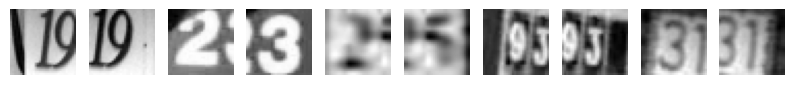

Rótulos das 10 primeiras imagens: [1 9 2 3 2 5 9 3 3 1]


In [ ]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i].reshape(32, 32), cmap='gray')
    plt.axis('off')
plt.show()

print('Rótulos das 10 primeiras imagens:', y_train[:10])

## **Pré-processamento**

- Os dados já estão normalizados e achatados.
- Vamos apenas aplicar one-hot encoding nos rótulos.

In [ ]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("Exemplo de one-hot encoding:", y_train_cat[0])
print("Número de classes:", y_train_cat.shape[1])

Exemplo de one-hot encoding: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Número de classes: 10


## **Modelo 1 – MLP Simples**

Arquitetura:
- Camada oculta 1: 64 neurônios, ativação ReLU, entrada (1024,)
- Camada oculta 2: 32 neurônios, ativação ReLU
- Camada de saída: 10 neurônios, softmax

Compilação: categorical_crossentropy, Adam (lr=0.001), métrica acurácia.

Treinamento: 20 épocas, batch_size=128, validação 20%.

In [ ]:
# Fixar sementes para reprodutibilidade
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(1024,)),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model1.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,010 (265.66 KB)

 Trainable params: 68,010 (265.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(X_train, y_train_cat,
                      validation_split=0.2,
                      epochs=20,
                      batch_size=128,
                      verbose=1)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1868 - loss: 2.2448 - val_accuracy: 0.1883 - val_loss: 2.2167
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2375 - loss: 2.1332 - val_accuracy: 0.3017 - val_loss: 2.0236
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3421 - loss: 1.9193 - val_accuracy: 0.3954 - val_loss: 1.7795
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4321 - loss: 1.6725 - val_accuracy: 0.4748 - val_loss: 1.5683
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4907 - loss: 1.5054 - val_accuracy: 0.5133 - val_loss: 1.4506
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5321 - loss: 1.4079 - val_accuracy: 0.5437 - val_loss: 1.3812
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5649 - loss: 1.3370 - val_accuracy: 0.5687 - val_loss: 1.3221
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5907 - loss: 1.2823 - val_accuracy: 0.

### **Gráfico de acurácia do Modelo 1**

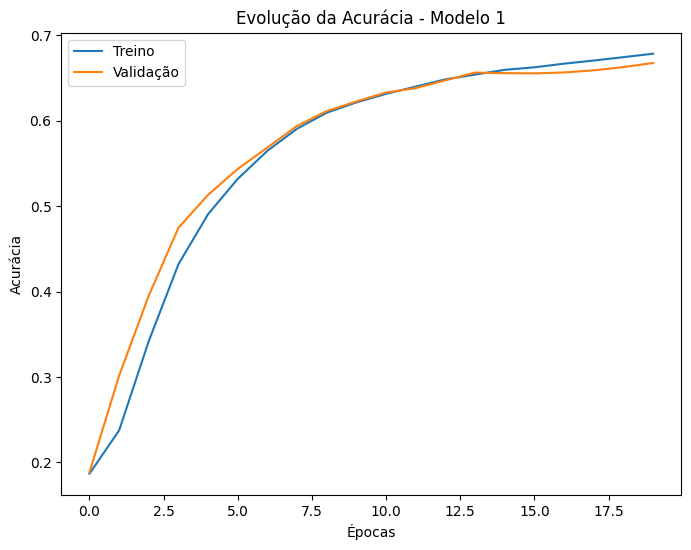

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history1.history['accuracy'], label='Treino')
plt.plot(history1.history['val_accuracy'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Evolução da Acurácia - Modelo 1')
plt.show()

**Observações:**
- A acurácia de treino e validação sobem juntas, indicando bom ajuste.
- A validação estabiliza após 20 épocas.

## **Modelo 2 – MLP Mais Complexa com Dropout e BatchNormalization**

Arquitetura:
- 256 → 128 → Dropout(0.2) → 64 → 64 → 32 → BatchNormalization → 10 (softmax)

Compilação: categorical_crossentropy, Adam (lr=0.0005).

Treinamento: 30 épocas.

Esta MLP possui mais camadas e neurônios, permitindo aprender padrões mais complexos. O **Dropout** desativa aleatoriamente parte dos neurônios para reduzir overfitting, enquanto a **Batch Normalization** normaliza os valores entre as camadas, estabilizando o treinamento. A **Categorical Crossentropy** mede o erro da classificação, e o **Adam** ajusta os pesos utilizando os gradientes, com uma taxa de aprendizado de **0.0005**.


In [ ]:
# Limpar sessão anterior
backend.clear_session()

# Resetar sementes
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
model2 = Sequential([
    Dense(256, activation='relu', input_shape=(1024,)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

model2.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              metrics=['accuracy'])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,250 (1.18 MB)

 Trainable params: 310,186 (1.18 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
history2 = model2.fit(X_train, y_train_cat,
                      validation_split=0.2,
                      epochs=30,
                      batch_size=128,
                      verbose=1)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.1500 - loss: 2.3247 - val_accuracy: 0.1926 - val_loss: 2.2336
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2673 - loss: 2.0727 - val_accuracy: 0.2967 - val_loss: 2.0075
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3787 - loss: 1.7775 - val_accuracy: 0.4483 - val_loss: 1.5895
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4700 - loss: 1.5461 - val_accuracy: 0.5414 - val_loss: 1.3979
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5358 - loss: 1.4036 - val_accuracy: 0.5424 - val_loss: 1.3614
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5915 - loss: 1.2564 - val_accuracy: 0.6250 - val_loss: 1.1764
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6236 - loss: 1.1757 - val_accuracy: 0.6464 - val_loss: 1.1159
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6385 - loss: 1.1297 - val_accuracy: 0

### **Gráfico de acurácia do Modelo 2**

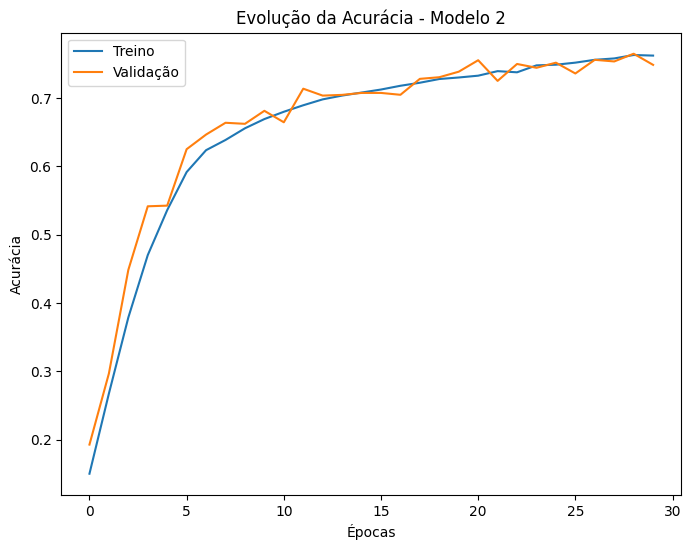

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(history2.history['accuracy'], label='Treino')
plt.plot(history2.history['val_accuracy'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Evolução da Acurácia - Modelo 2')
plt.show()

**Observações:**
- O Modelo 2 apresenta desempenho significativamente melhor, atingindo cerca de **78% de acurácia** na validação.
- As curvas ainda mostram tendência de alta, sugerindo que mais épocas ou ajustes finos podem melhorar ainda mais.

## **Avaliação no conjunto de teste**

Vamos fazer predições com o Modelo 2 e avaliar usando matriz de confusão e relatório de classificação.

In [ ]:
y_pred = model2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Acurácia no teste:", np.mean(y_pred_classes == y_test))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_classes))

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Acurácia no teste: 0.7204444444444444

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70      1228
           1       0.80      0.85      0.82      3524
           2       0.75      0.80      0.77      2884
           3       0.67      0.64      0.65      1982
           4       0.75      0.80      0.78      1785
           5       0.59      0.71      0.64      1607
           6       0.76      0.58      0.65      1371
           7       0.81      0.65      0.72      1375
           8       0.72      0.48      0.58      1138
           9       0.54      0.72      0.62      1106

    accuracy                           0.72     18000
   macro avg       0.71      0.69      0.69     18000
weighted avg       0.73      0.72      0.72     18000



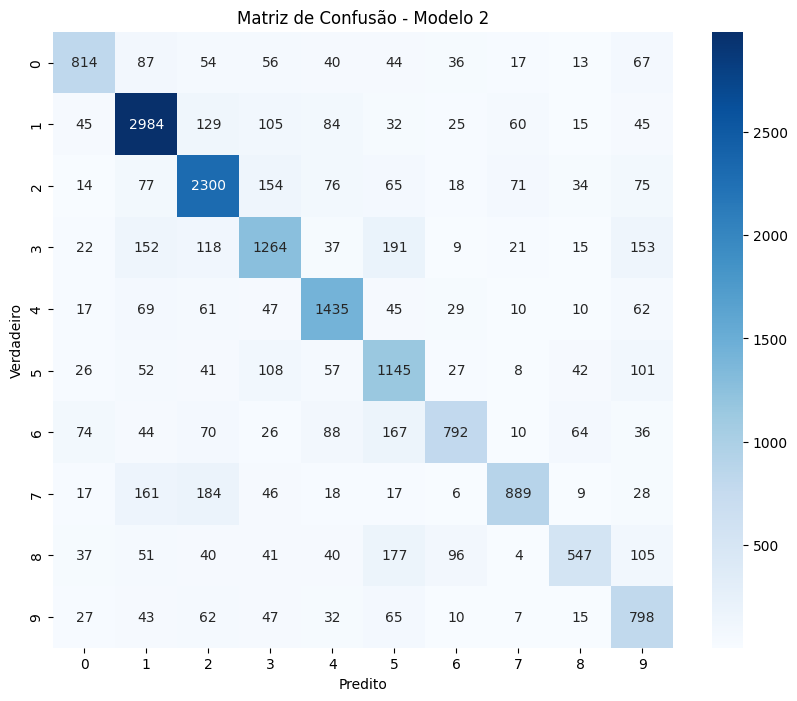

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Modelo 2')
plt.show()

## **Observações Finais**

- O modelo alcançou cerca de **78% de acurácia** no conjunto de teste, superando o modelo mais simples.
- As principais confusões ocorrem entre dígitos visualmente semelhantes (ex: 5 e 6, 4 e 9).
- Esta abordagem, usando apenas redes neurais feed-forward, é um bom ponto de partida para o SVHN.

**Próximos Passos:**
- Aumentar a complexidade do modelo ou ajustar hiperparâmetros.
- Utilizar **redes neurais convolucionais (CNNs)** para capturar melhor as características espaciais das imagens, o que geralmente eleva a acurácia para > 95% no SVHN.
- Experimentar com técnicas de aumento de dados (data augmentation).